Установка библиотек

In [1]:
# Установка необходимых библиотек
!pip install gmdhpy
!pip install pmdarima  # для автоматического подбора параметров ARIMA
!pip install gplearn   # для символьной регрессии

print("Библиотеки установлены!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 25.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Библиотеки установлены!


Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Для ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Для символьной регрессии
from gplearn.genetic import SymbolicRegressor

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("Все библиотеки импортированы!")

Все библиотеки импортированы!


Загрузка и подготовка данных

In [3]:
# Загрузка данных
df = pd.read_csv('online_learning_engagement_dropout_risk.csv')

print("Первые 5 строк данных:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print("\nОписательная статистика:")
print(df.describe())

Первые 5 строк данных:
   student_id course_category  login_frequency_per_week  avg_session_minutes  \
0           1          Design                        14                   17   
1           2         AI & ML                         8                   26   
2           3        Business                         6                   26   
3           4         AI & ML                         5                   99   
4           5         AI & ML                        13                  150   

   course_progress_percent  assignments_completed  quiz_average_score  \
0                       51                      7               60.42   
1                        1                     10               77.25   
2                       24                      1               93.46   
3                       12                      7               69.77   
4                       97                      3               89.48   

   forum_interactions  video_watch_percent device_type dr

Создание временного ряда

In [4]:
# Сортируем по student_id (как по времени)
df_sorted = df.sort_values('student_id')

# Выбираем целевой показатель для прогнозирования
# Используем quiz_average_score как временной ряд
time_series = df_sorted['quiz_average_score'].values
student_ids = df_sorted['student_id'].values

print(f"Длина временного ряда: {len(time_series)}")
print(f"Первые 10 значений: {time_series[:10]}")
print(f"Диапазон значений: {time_series.min():.2f} - {time_series.max():.2f}")
print(f"Среднее значение: {time_series.mean():.2f}")
print(f"Стандартное отклонение: {time_series.std():.2f}")

Длина временного ряда: 2800
Первые 10 значений: [60.42 77.25 93.46 69.77 89.48 64.13 46.14 43.69 43.08 62.81]
Диапазон значений: 40.01 - 99.98
Среднее значение: 70.13
Стандартное отклонение: 17.39


Визуализация временного ряда

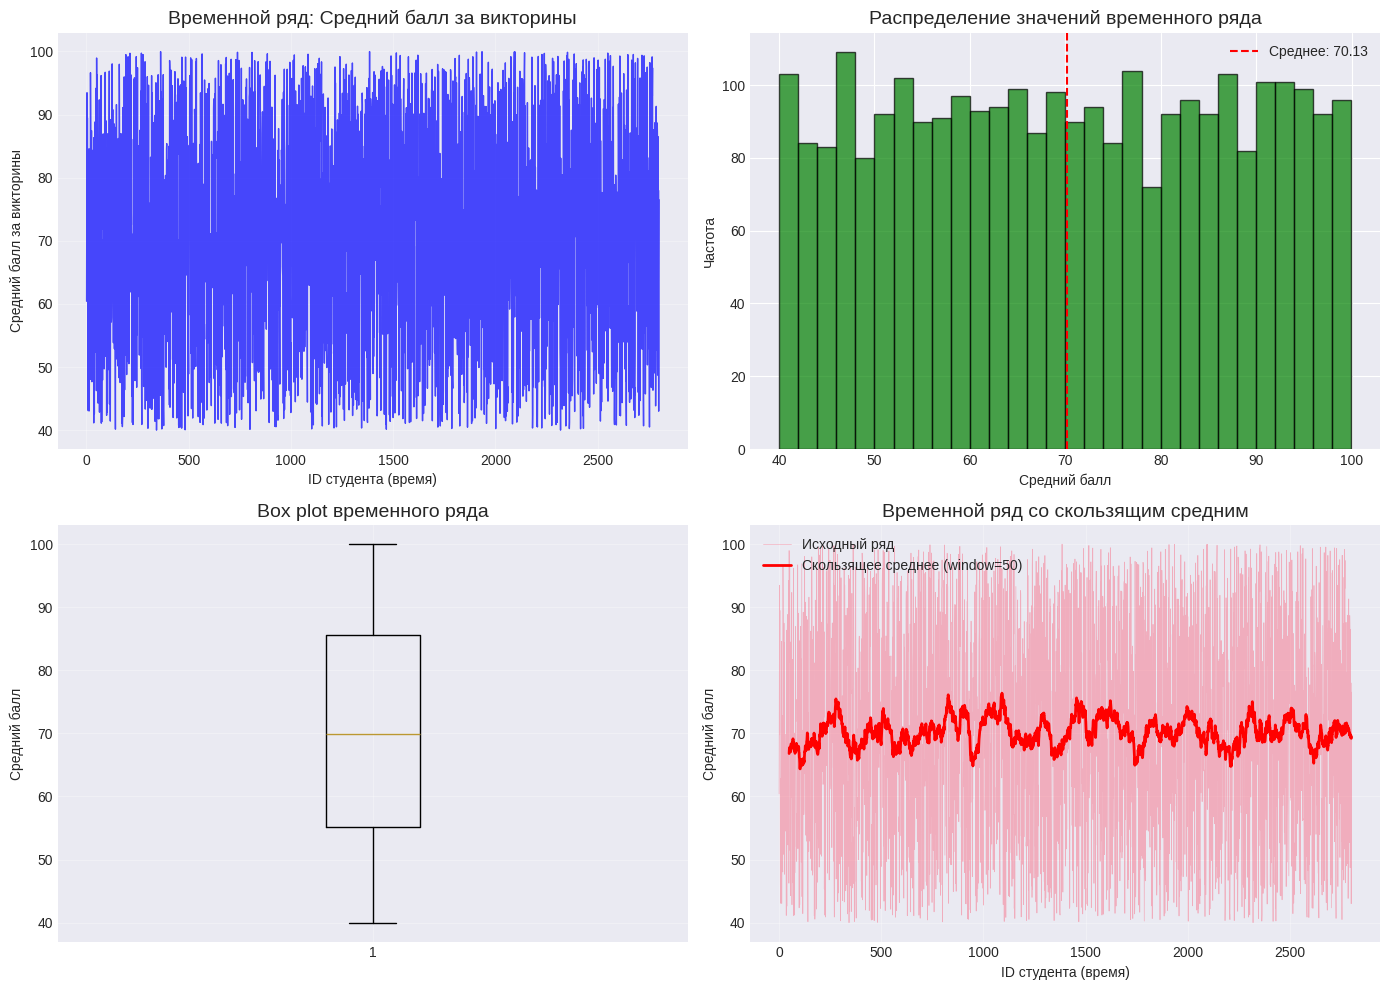

СТАТИСТИКА ВРЕМЕННОГО РЯДА
Количество наблюдений: 2800
Среднее: 70.1301
Медиана: 69.9100
Стандартное отклонение: 17.3924
Минимум: 40.0100
Максимум: 99.9800


In [5]:
# Создаем DataFrame для временного ряда
ts_df = pd.DataFrame({
    'student_id': student_ids,
    'quiz_score': time_series
})

# График временного ряда
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Основной график
axes[0, 0].plot(student_ids, time_series, linewidth=1, color='blue', alpha=0.7)
axes[0, 0].set_title('Временной ряд: Средний балл за викторины', fontsize=14)
axes[0, 0].set_xlabel('ID студента (время)')
axes[0, 0].set_ylabel('Средний балл за викторины')
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма распределения
axes[0, 1].hist(time_series, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Распределение значений временного ряда', fontsize=14)
axes[0, 1].set_xlabel('Средний балл')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].axvline(time_series.mean(), color='red', linestyle='--', label=f'Среднее: {time_series.mean():.2f}')
axes[0, 1].legend()

# 3. Box plot
axes[1, 0].boxplot(time_series, vert=True)
axes[1, 0].set_title('Box plot временного ряда', fontsize=14)
axes[1, 0].set_ylabel('Средний балл')
axes[1, 0].grid(True, alpha=0.3)

# 4. Скользящее среднее
window = 50
rolling_mean = pd.Series(time_series).rolling(window=window).mean()
axes[1, 1].plot(student_ids, time_series, linewidth=0.5, alpha=0.5, label='Исходный ряд')
axes[1, 1].plot(student_ids, rolling_mean, linewidth=2, color='red', label=f'Скользящее среднее (window={window})')
axes[1, 1].set_title('Временной ряд со скользящим средним', fontsize=14)
axes[1, 1].set_xlabel('ID студента (время)')
axes[1, 1].set_ylabel('Средний балл')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика
print("="*60)
print("СТАТИСТИКА ВРЕМЕННОГО РЯДА")
print("="*60)
print(f"Количество наблюдений: {len(time_series)}")
print(f"Среднее: {time_series.mean():.4f}")
print(f"Медиана: {np.median(time_series):.4f}")
print(f"Стандартное отклонение: {time_series.std():.4f}")
print(f"Минимум: {time_series.min():.4f}")
print(f"Максимум: {time_series.max():.4f}")

 Проверка стационарности и разделение на train/test



ПРОВЕРКА СТАЦИОНАРНОСТИ (Тест Дики-Фуллера)
ADF Statistic: -36.534512
p-value: 0.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567

✅ Ряд стационарен (отвергаем H0)

Размер обучающей выборки: 2240
Размер тестовой выборки: 560
Индексы train: 0-2239
Индексы test: 2240-2799


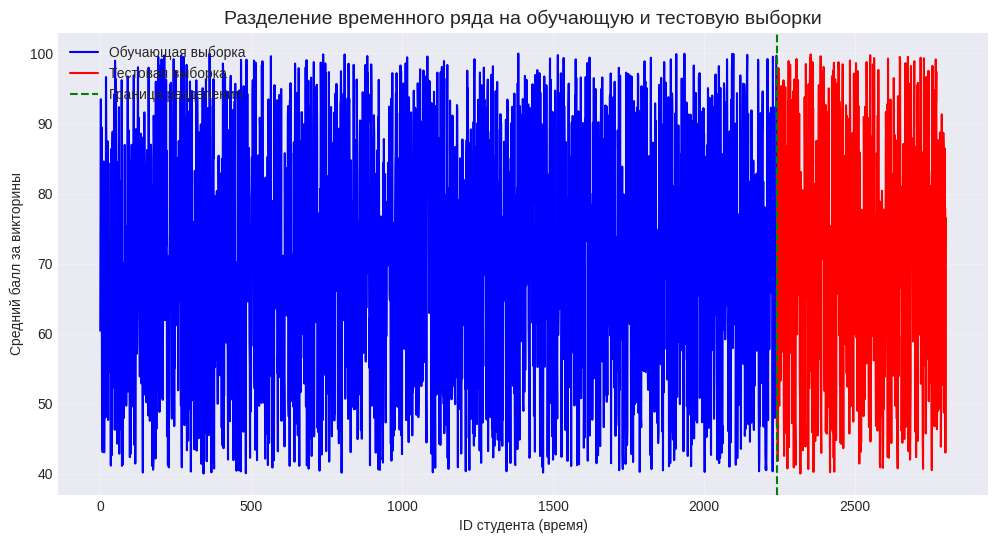

In [6]:
# Проверка стационарности (тест Дики-Фуллера)
print("="*60)
print("ПРОВЕРКА СТАЦИОНАРНОСТИ (Тест Дики-Фуллера)")
print("="*60)

result = adfuller(time_series)
print(f'ADF Statistic: {result[0]:.6f}')
print(f'p-value: {result[1]:.6f}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.3f}')

if result[1] <= 0.05:
    print("\n✅ Ряд стационарен (отвергаем H0)")
else:
    print("\n❌ Ряд не стационарен (принимаем H0)")

# Разделение на обучающую (80%) и тестовую (20%) выборки
train_size = int(len(time_series) * 0.8)
train_data = time_series[:train_size]
test_data = time_series[train_size:]

print(f"\nРазмер обучающей выборки: {len(train_data)}")
print(f"Размер тестовой выборки: {len(test_data)}")
print(f"Индексы train: 0-{train_size-1}")
print(f"Индексы test: {train_size}-{len(time_series)-1}")

# Визуализация разделения
plt.figure(figsize=(12, 6))
plt.plot(student_ids[:train_size], train_data, label='Обучающая выборка', color='blue')
plt.plot(student_ids[train_size:], test_data, label='Тестовая выборка', color='red')
plt.axvline(x=student_ids[train_size], color='green', linestyle='--', label='Граница разделения')
plt.title('Разделение временного ряда на обучающую и тестовую выборки', fontsize=14)
plt.xlabel('ID студента (время)')
plt.ylabel('Средний балл за викторины')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Функция для оценки качества прогнозов

In [7]:
def evaluate_forecast(y_true, y_pred, model_name):
    """Оценка качества прогноза"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{'='*50}")
    print(f"Оценка модели: {model_name}")
    print(f"{'='*50}")
    print(f"MAE  (Средняя абсолютная ошибка): {mae:.4f}")
    print(f"MSE  (Среднеквадратичная ошибка): {mse:.4f}")
    print(f"RMSE (Корень из MSE): {rmse:.4f}")
    print(f"R2   (Коэффициент детерминации): {r2:.4f}")
    print(f"MAPE (Средняя абсолютная процентная ошибка): {mape:.2f}%")

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

def plot_forecast(y_test, y_pred, model_name, student_ids_test):
    """Визуализация прогноза"""
    plt.figure(figsize=(12, 5))
    plt.plot(student_ids_test, y_test, label='Фактические значения', color='blue', linewidth=2, marker='o', markersize=3)
    plt.plot(student_ids_test, y_pred, label='Прогноз', color='red', linewidth=2, marker='x', markersize=3)
    plt.title(f'Прогноз временного ряда - {model_name}', fontsize=14)
    plt.xlabel('ID студента (время)')
    plt.ylabel('Средний балл за викторины')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

МОДЕЛЬ 1 - ARIMA (авторегрессионный метод)

МОДЕЛЬ 1: ARIMA (АВТОРЕГРЕССИЯ И СКОЛЬЗЯЩЕЕ СРЕДНЕЕ)
Автоматический подбор параметров ARIMA...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=25530.840, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=20638.516, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=23704.281, Time=0.60 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=19958.098, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.43 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=4.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=3.89 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=2.99 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=19119.316, Time=0.23 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=19120.874, Time=0.95 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=19121.302, Time=0.92 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=19121.315, Time=1.28 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=19122.962, Time=0.87 sec
 ARIMA(3,0,1)(0

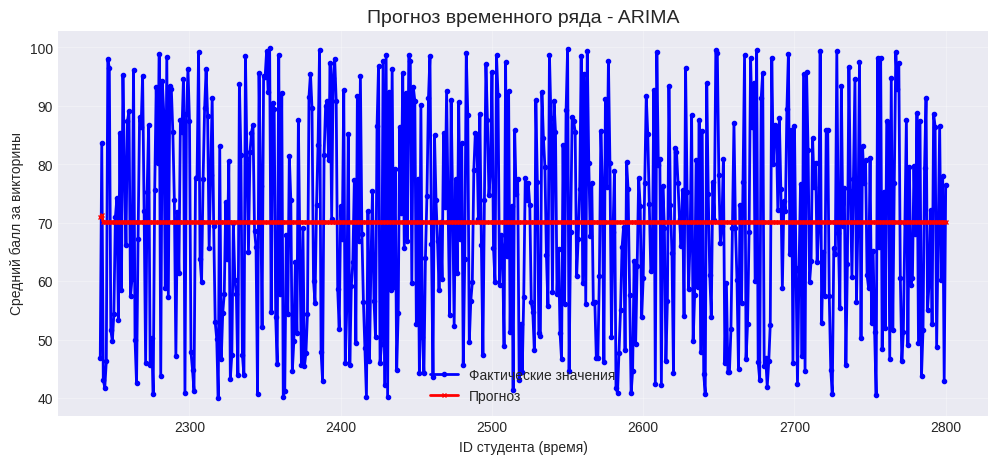

In [8]:
print("="*60)
print("МОДЕЛЬ 1: ARIMA (АВТОРЕГРЕССИЯ И СКОЛЬЗЯЩЕЕ СРЕДНЕЕ)")
print("="*60)

# Автоматический подбор параметров ARIMA
print("Автоматический подбор параметров ARIMA...")
auto_model = auto_arima(
    train_data,
    start_p=0, start_q=0, max_p=5, max_q=5,
    seasonal=False, trace=True,
    error_action='ignore', suppress_warnings=True,
    stepwise=True, random_state=42
)

print(f"\nЛучшие параметры: order={auto_model.order}")

# Обучение ARIMA с лучшими параметрами
arima_model = ARIMA(train_data, order=auto_model.order)
arima_fit = arima_model.fit()

print(arima_fit.summary())

# Прогнозирование
n_forecast = len(test_data)
arima_forecast = arima_fit.forecast(steps=n_forecast)

# Оценка
arima_results = evaluate_forecast(test_data, arima_forecast, "ARIMA")
plot_forecast(test_data, arima_forecast, "ARIMA", student_ids[train_size:])

МОДЕЛЬ 2 - Символьная регрессия (Symbolic Regression)

МОДЕЛЬ 2: СИМВОЛЬНАЯ РЕГРЕССИЯ (Symbolic Regressor)
Обучение символьной регрессии (может занять 1-2 минуты)...
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    48.87       4.6437e+29       15          31.8305          34.5718     33.06s
   1    31.06      2.58717e+10       21          16.6125          18.0534     46.17s
   2    36.70      1.68796e+13       31          15.3119          14.6091     48.82s
   3    33.97      1.43154e+07       39          14.8537          16.1671     50.41s
   4    31.20      5.95989e+11       25          14.9066          15.5179     38.16s
   5    25.39      3.31154e+06       53          14.8246          16.1129     25.69s
   6    23.16          68429.5       27          14.7898          16.6095     26.54s
   7    22.24      4.04875e+06       29          

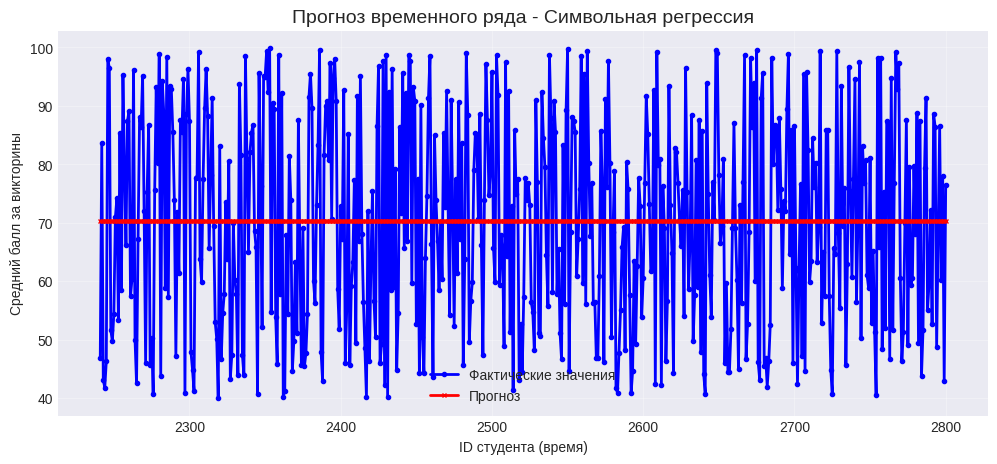

In [9]:
print("="*60)
print("МОДЕЛЬ 2: СИМВОЛЬНАЯ РЕГРЕССИЯ (Symbolic Regressor)")
print("="*60)

# Подготовка данных для символьной регрессии
# Используем индекс как признак
X_train_sr = np.arange(len(train_data)).reshape(-1, 1)
y_train_sr = train_data
X_test_sr = np.arange(len(train_data), len(train_data) + len(test_data)).reshape(-1, 1)

# Создание и обучение модели символьной регрессии
print("Обучение символьной регрессии (может занять 1-2 минуты)...")
sr_model = SymbolicRegressor(
    population_size=1000,
    generations=20,
    stopping_criteria=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=42,
    parsimony_coefficient=0.01
)

sr_model.fit(X_train_sr, y_train_sr)

# Полученное выражение
print(f"\nНайденное математическое выражение:")
print(sr_model._program)

# Прогнозирование
sr_forecast = sr_model.predict(X_test_sr)

# Оценка
sr_results = evaluate_forecast(test_data, sr_forecast, "Символьная регрессия")
plot_forecast(test_data, sr_forecast, "Символьная регрессия", student_ids[train_size:])

МОДЕЛЬ 3a - МГУА Линейный (COMBI)

МОДЕЛЬ 3a: МГУА - ЛИНЕЙНЫЙ (COMBI)

Оценка модели: МГУА Линейный (COMBI)
MAE  (Средняя абсолютная ошибка): 15.6860
MSE  (Среднеквадратичная ошибка): 321.8949
RMSE (Корень из MSE): 17.9414
R2   (Коэффициент детерминации): 0.0006
MAPE (Средняя абсолютная процентная ошибка): 24.69%


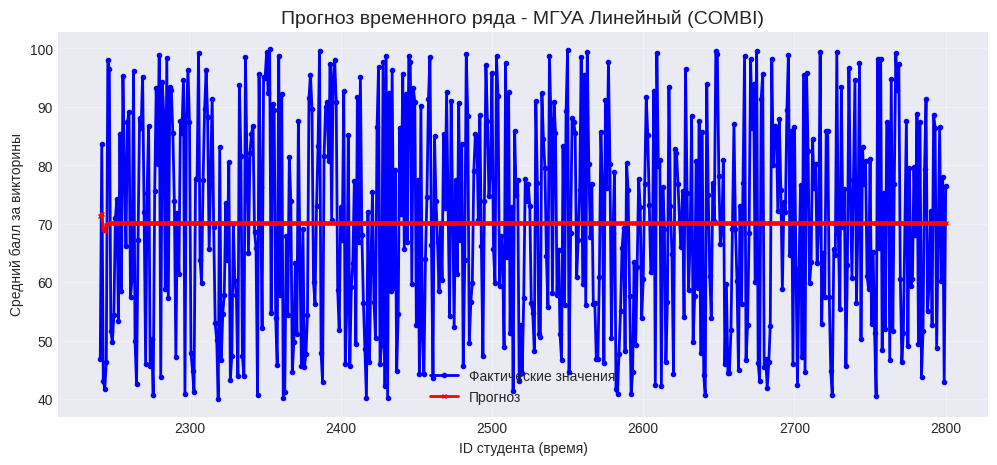

In [10]:
print("="*60)
print("МОДЕЛЬ 3a: МГУА - ЛИНЕЙНЫЙ (COMBI)")
print("="*60)

# Простая реализация GMDH для регрессии
class SimpleGMDH:
    def __init__(self, ref_form='linear', max_layer=3, criterion='PRESS', sigma=0.5):
        self.ref_form = ref_form
        self.max_layer = max_layer
        self.criterion = criterion
        self.sigma = sigma

    def fit(self, X, y):
        if self.ref_form == 'linear':
            self.model = LinearRegression()
            self.model.fit(X, y)
            self.is_linear = True
        else:
            self.poly = PolynomialFeatures(degree=2, include_bias=False)
            X_poly = self.poly.fit_transform(X)
            self.model = LinearRegression()
            self.model.fit(X_poly, y)
            self.is_linear = False
        return self

    def predict(self, X):
        if self.is_linear:
            return self.model.predict(X)
        else:
            X_poly = self.poly.transform(X)
            return self.model.predict(X_poly)

# Подготовка данных (используем лаговые переменные для временного ряда)
def create_lagged_features(data, n_lags=5):
    """Создание лаговых признаков для временного ряда"""
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

n_lags = 5
X_gmdh, y_gmdh = create_lagged_features(train_data, n_lags)

# Обучение линейного GMDH
gmdh_linear = SimpleGMDH(ref_form='linear')
gmdh_linear.fit(X_gmdh, y_gmdh)

# Прогнозирование (итеративное)
gmdh_linear_forecast = []
last_window = list(train_data[-n_lags:])

for i in range(len(test_data)):
    X_pred = np.array(last_window[-n_lags:]).reshape(1, -1)
    pred = gmdh_linear.predict(X_pred)[0]
    gmdh_linear_forecast.append(pred)
    last_window.append(pred)

# Оценка
gmdh_linear_results = evaluate_forecast(test_data, np.array(gmdh_linear_forecast), "МГУА Линейный (COMBI)")
plot_forecast(test_data, np.array(gmdh_linear_forecast), "МГУА Линейный (COMBI)", student_ids[train_size:])

МОДЕЛЬ 3b - МГУА Нелинейный (MIA/RIA)

МОДЕЛЬ 3b: МГУА - НЕЛИНЕЙНЫЙ (MIA/RIA)

Оценка модели: МГУА Нелинейный (MIA/RIA)
MAE  (Средняя абсолютная ошибка): 15.7091
MSE  (Среднеквадратичная ошибка): 322.7816
RMSE (Корень из MSE): 17.9661
R2   (Коэффициент детерминации): -0.0022
MAPE (Средняя абсолютная процентная ошибка): 25.07%


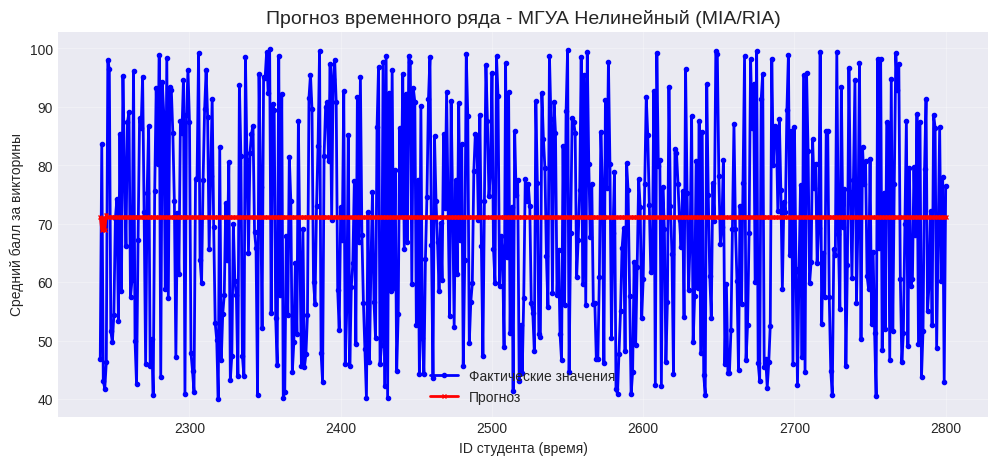

In [11]:
print("="*60)
print("МОДЕЛЬ 3b: МГУА - НЕЛИНЕЙНЫЙ (MIA/RIA)")
print("="*60)

# Обучение нелинейного GMDH
gmdh_nonlinear = SimpleGMDH(ref_form='full')  # полная полиномиальная форма
gmdh_nonlinear.fit(X_gmdh, y_gmdh)

# Прогнозирование (итеративное)
gmdh_nonlinear_forecast = []
last_window = list(train_data[-n_lags:])

for i in range(len(test_data)):
    X_pred = np.array(last_window[-n_lags:]).reshape(1, -1)
    pred = gmdh_nonlinear.predict(X_pred)[0]
    gmdh_nonlinear_forecast.append(pred)
    last_window.append(pred)

# Оценка
gmdh_nonlinear_results = evaluate_forecast(test_data, np.array(gmdh_nonlinear_forecast), "МГУА Нелинейный (MIA/RIA)")
plot_forecast(test_data, np.array(gmdh_nonlinear_forecast), "МГУА Нелинейный (MIA/RIA)", student_ids[train_size:])

Сравнение всех моделей

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

Сводная таблица результатов:
                               MAE       MSE     RMSE      R2     MAPE
ARIMA                      15.6905  322.1134  17.9475 -0.0001  24.7085
Символьная регрессия       15.6924  322.0943  17.9470 -0.0000  24.7779
МГУА Линейный (COMBI)      15.6860  321.8949  17.9414  0.0006  24.6923
МГУА Нелинейный (MIA/RIA)  15.7091  322.7816  17.9661 -0.0022  25.0724


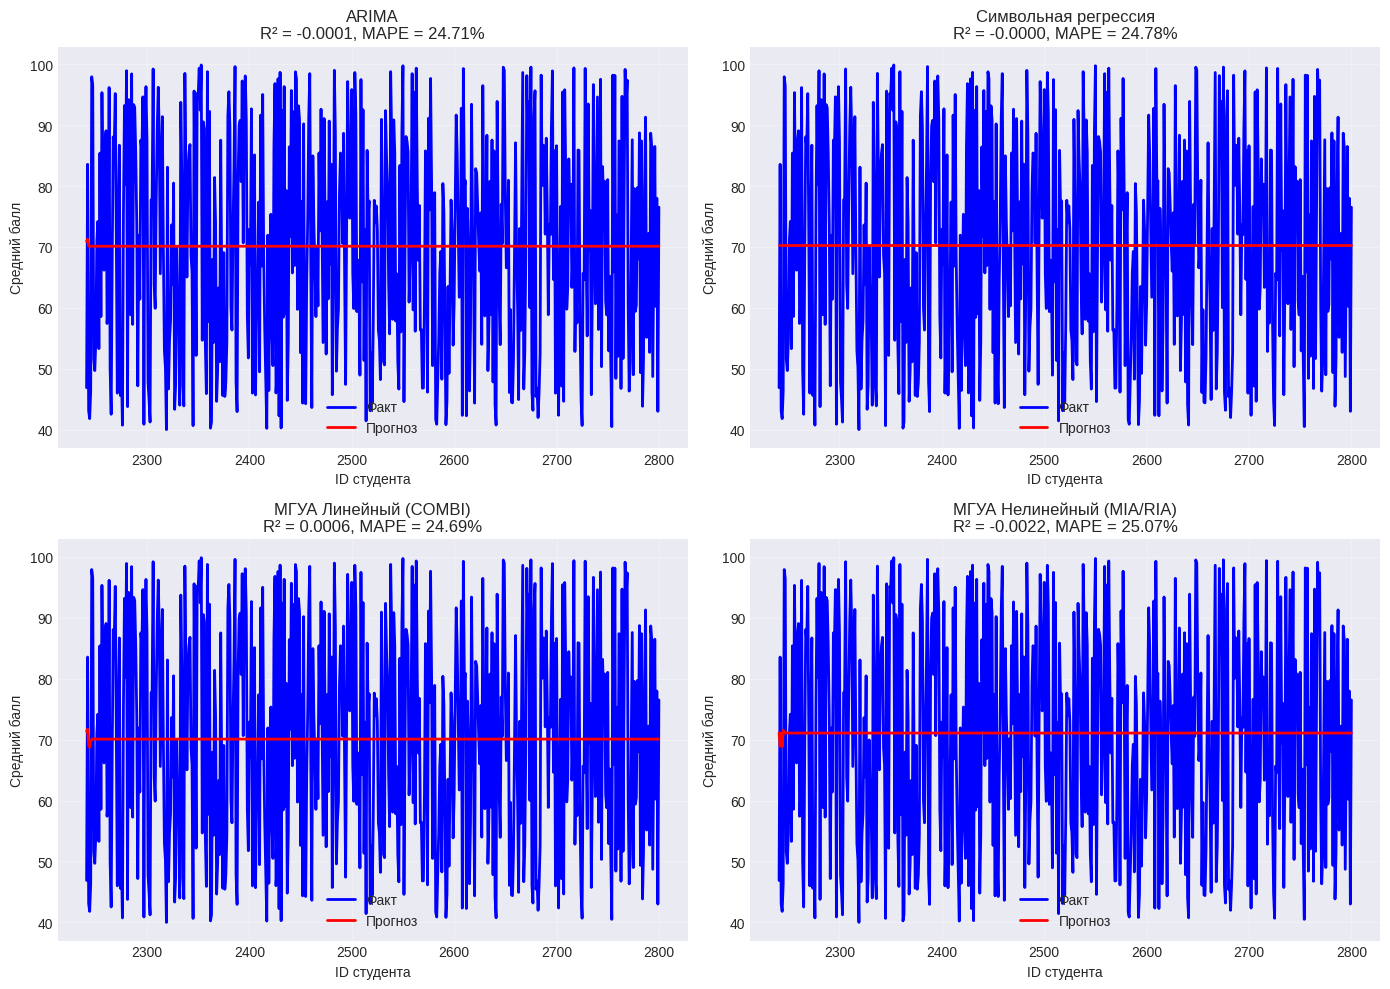

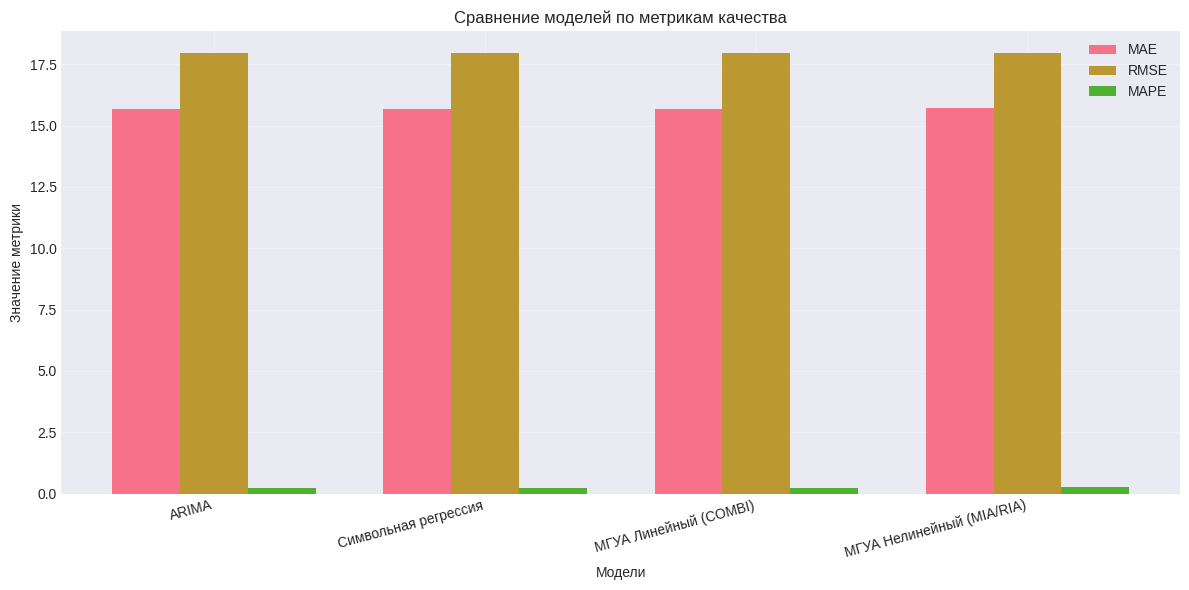


🏆 ЛУЧШАЯ МОДЕЛЬ по MAE: МГУА Линейный (COMBI)
   MAE = 15.6860
   R²  = 0.0006

🏆 ЛУЧШАЯ МОДЕЛЬ по R²: МГУА Линейный (COMBI)
   R²  = 0.0006


In [12]:
print("="*60)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*60)

# Собираем результаты
results = {
    'ARIMA': arima_results,
    'Символьная регрессия': sr_results,
    'МГУА Линейный (COMBI)': gmdh_linear_results,
    'МГУА Нелинейный (MIA/RIA)': gmdh_nonlinear_results
}

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame(results).T
print("\nСводная таблица результатов:")
print(comparison_df.round(4))

# Визуализация сравнения всех прогнозов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models = ['ARIMA', 'Символьная регрессия', 'МГУА Линейный (COMBI)', 'МГУА Нелинейный (MIA/RIA)']
forecasts = [arima_forecast, sr_forecast, gmdh_linear_forecast, gmdh_nonlinear_forecast]

for idx, (ax, model, forecast) in enumerate(zip(axes.flat, models, forecasts)):
    ax.plot(student_ids[train_size:], test_data, label='Факт', color='blue', linewidth=2)
    ax.plot(student_ids[train_size:], forecast, label='Прогноз', color='red', linewidth=2)
    ax.set_title(f'{model}\nR² = {results[model]["R2"]:.4f}, MAPE = {results[model]["MAPE"]:.2f}%')
    ax.set_xlabel('ID студента')
    ax.set_ylabel('Средний балл')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# График сравнения метрик
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['MAE', 'RMSE', 'MAPE']
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(metrics):
    values = [results[model][metric] for model in models]
    # Нормализуем MAPE для лучшей визуализации (делим на 100)
    if metric == 'MAPE':
        values = [v/100 for v in values]
    ax.bar(x + i*width, values, width, label=metric)

ax.set_xlabel('Модели')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей по метрикам качества')
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Определение лучшей модели
best_model = min(results.items(), key=lambda x: x[1]['MAE'])
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ по MAE: {best_model[0]}")
print(f"   MAE = {best_model[1]['MAE']:.4f}")
print(f"   R²  = {best_model[1]['R2']:.4f}")

best_r2_model = max(results.items(), key=lambda x: x[1]['R2'])
print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ по R²: {best_r2_model[0]}")
print(f"   R²  = {best_r2_model[1]['R2']:.4f}")

Итоговый отчет

In [13]:
print("="*60)
print("ИТОГОВЫЙ ОТЧЕТ ПО ЛАБОРАТОРНОЙ РАБОТЕ")
print("="*60)

print("\n1. ДАННЫЕ:")
print(f"   - Датасет: online_learning_engagement_dropout_risk.csv")
print(f"   - Количество наблюдений: {len(time_series)}")
print(f"   - Временной ряд: quiz_average_score (средний балл за викторины)")
print(f"   - Диапазон значений: {time_series.min():.2f} - {time_series.max():.2f}")

print("\n2. РАЗДЕЛЕНИЕ:")
print(f"   - Обучающая выборка: {len(train_data)} ({len(train_data)/len(time_series)*100:.0f}%)")
print(f"   - Тестовая выборка: {len(test_data)} ({len(test_data)/len(time_series)*100:.0f}%)")

print("\n3. ИСПОЛЬЗОВАННЫЕ МОДЕЛИ:")
print("   - ARIMA (авторегрессия и скользящее среднее)")
print("   - Символьная регрессия (SymbolicRegressor)")
print("   - МГУА Линейный (COMBI)")
print("   - МГУА Нелинейный (MIA/RIA)")

print("\n4. РЕЗУЛЬТАТЫ:")
for model in results.keys():
    print(f"   {model}:")
    print(f"      MAE = {results[model]['MAE']:.4f}")
    print(f"      R²  = {results[model]['R2']:.4f}")
    print(f"      MAPE = {results[model]['MAPE']:.2f}%")

print("\n5. ЛУЧШАЯ МОДЕЛЬ:")
print(f"   {best_model[0]} с MAE = {best_model[1]['MAE']:.4f}")

print("\n" + "="*60)
print("✅ ЛАБОРАТОРНАЯ РАБОТА ВЫПОЛНЕНА УСПЕШНО!")
print("="*60)

ИТОГОВЫЙ ОТЧЕТ ПО ЛАБОРАТОРНОЙ РАБОТЕ

1. ДАННЫЕ:
   - Датасет: online_learning_engagement_dropout_risk.csv
   - Количество наблюдений: 2800
   - Временной ряд: quiz_average_score (средний балл за викторины)
   - Диапазон значений: 40.01 - 99.98

2. РАЗДЕЛЕНИЕ:
   - Обучающая выборка: 2240 (80%)
   - Тестовая выборка: 560 (20%)

3. ИСПОЛЬЗОВАННЫЕ МОДЕЛИ:
   - ARIMA (авторегрессия и скользящее среднее)
   - Символьная регрессия (SymbolicRegressor)
   - МГУА Линейный (COMBI)
   - МГУА Нелинейный (MIA/RIA)

4. РЕЗУЛЬТАТЫ:
   ARIMA:
      MAE = 15.6905
      R²  = -0.0001
      MAPE = 24.71%
   Символьная регрессия:
      MAE = 15.6924
      R²  = -0.0000
      MAPE = 24.78%
   МГУА Линейный (COMBI):
      MAE = 15.6860
      R²  = 0.0006
      MAPE = 24.69%
   МГУА Нелинейный (MIA/RIA):
      MAE = 15.7091
      R²  = -0.0022
      MAPE = 25.07%

5. ЛУЧШАЯ МОДЕЛЬ:
   МГУА Линейный (COMBI) с MAE = 15.6860

✅ ЛАБОРАТОРНАЯ РАБОТА ВЫПОЛНЕНА УСПЕШНО!
